# Objectif 

Date de création : 20/01/2025

Inversion des positions des OBS à partir des enregistrements des émissions actives. 

In [10]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# import gc

In [11]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

In [12]:
sys.path.append(project_root)
from publication.publication_figure import PubFigure, color 
from real_data_analysis.fiberscope_groix.src.localisation.loc_utils import (
    f,
    jac,
    inverse_obs_loc,
)

# from misc import equivalent_celerity, calc_wls, draw_ellipse

In [13]:
# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

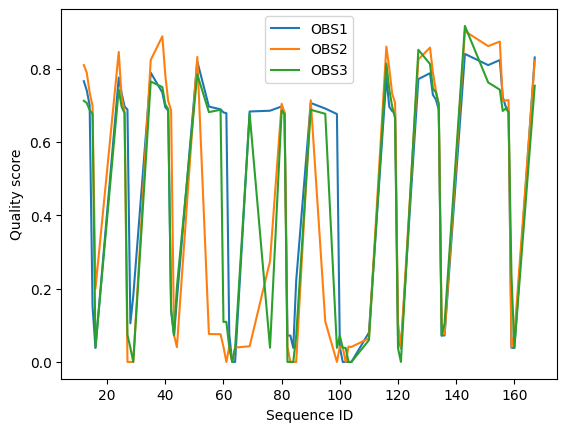

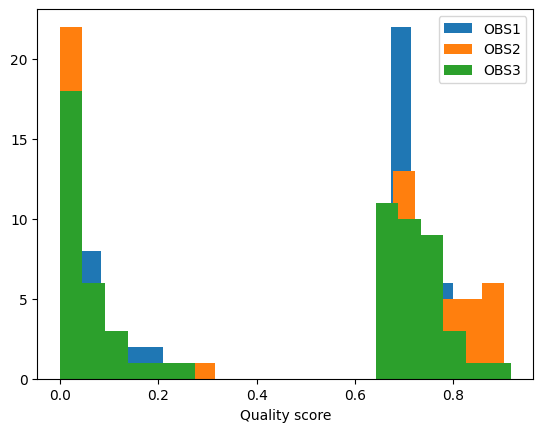

In [14]:
seq_ids = df_arr["Sequence_id"].unique()

# Plot f_score for each OBS

plt.figure()
for obs_id in [1, 2, 3]:
    col_name = f"f_score OBS{obs_id}"
    f_score = df_arr.groupby("Sequence_id")[col_name].mean()        # Mean over constant array = val (kick trick to compute it)

    # Plot f_score 
    plt.plot(seq_ids, f_score, label=f"OBS{obs_id}")

plt.xlabel("Sequence ID")
plt.ylabel("Quality score")
plt.legend()

plt.figure()
for obs_id in [1, 2, 3]:
    col_name = f"f_score OBS{obs_id}"
    f_score = df_arr.groupby("Sequence_id")[
        col_name
    ].mean()  # Mean over constant array = val (kick trick to compute it)

    # Plot f_score
    plt.hist(f_score, bins=20, label=f"OBS{obs_id}")

plt.xlabel("Quality score")
plt.legend()
# plt.ylabel("Quality score")

In [15]:
# Load synthetic data for comparison
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\synthetic_data\synthetic_data_20pos.nc"
ds_synthetic_arrivals = xr.open_dataset(fpath)
ds_synthetic_arrivals

<xarray.Dataset> Size: 2kB
Dimensions:         (id: 20)
Coordinates:
  * id              (id) int32 80B 0 1 2 3 4 5 6 7 8 ... 12 13 14 15 16 17 18 19
Data variables:
    x_no_noise      (id) float64 160B ...
    y_no_noise      (id) float64 160B ...
    z_no_noise      (id) float64 160B ...
    x               (id) float64 160B ...
    y               (id) float64 160B ...
    z               (id) float64 160B ...
    d_no_noise      (id) float64 160B ...
    d               (id) float64 160B ...
    t_arr_no_noise  (id) float64 160B ...
    t_arr           (id) float64 160B ...
Attributes:
    sigma_gps:   5
    sigma_time:  0.005

In [16]:
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

Estimated position : x = 3.855440124415561, y = -378.168876583584, z = -631.0474414511121
Residuals : index
0     -402877.107592
1     -404666.509485
2     -406497.168241
3     -411066.607043
4     -406177.309912
           ...      
645    390898.308498
646    389454.633974
647    384751.607685
648    378433.486877
649    376938.318364
Name: Measured propagation time OBS1, Length: 190, dtype: float64
Final cost : 170582267912107.3
[[2351.50362413 -504.24283449 -387.93982416]
 [-504.24283449 2474.12059392 -163.50862107]
 [-387.93982416 -163.50862107 2830.82878716]]
Estimated position : x = 304.2370659088913, y = 10.161736283919064, z = 60.13210161396677
Residuals : index
0      9.376055e+05
1      9.606774e+05
2      9.571738e+05
3      9.647946e+05
4      9.724456e+05
           ...     
645   -1.153118e+06
646   -1.152452e+06
647   -1.164379e+06
648   -1.156079e+06
649   -1.148266e+06
Name: Measured propagation time OBS2, Length: 270, dtype: float64
Final cost : 228531844665154.38
[[

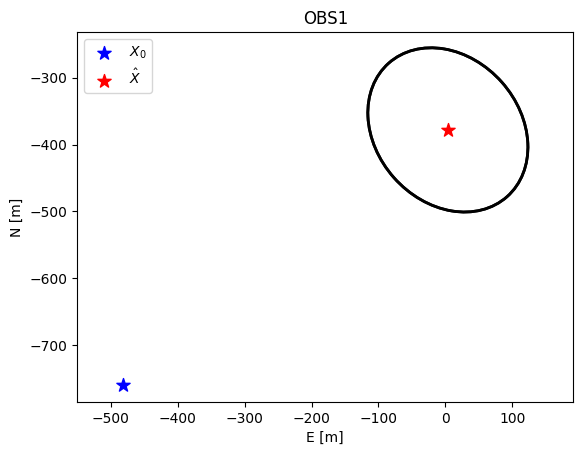

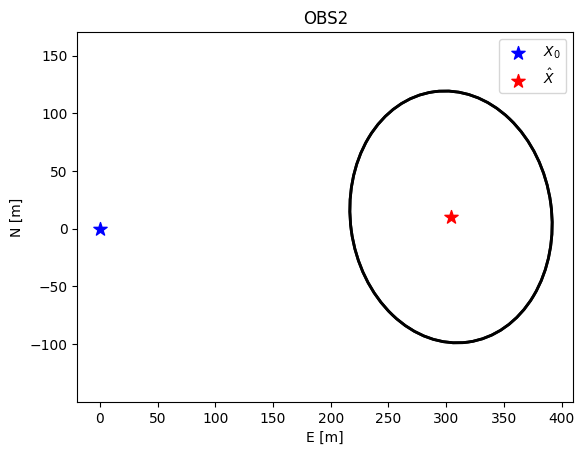

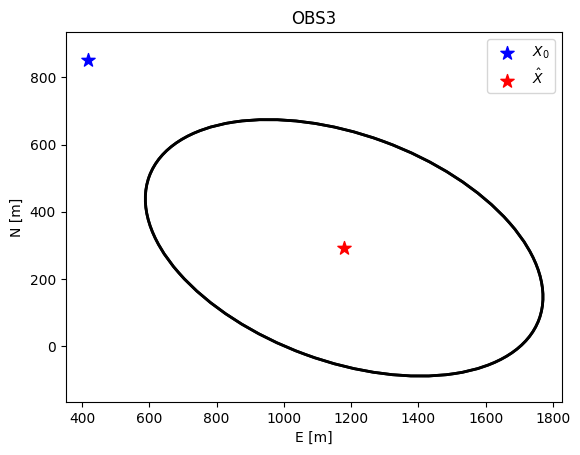

In [17]:
# Inverse position
min_f_score = 0.7

for obs_id in [1, 2, 3]:
    inverse_obs_loc(df_arr, ds_gps, obs_id, min_f_score, plot=True, verbose=True)